# Images and Convolutional Neural Networks

* Images -> Pixels -> Picture elements

* Each pixel contains color information

* In this section, we will use the Kaggle [Cloud Photos dataset](https://www.kaggle.com/datasets/jockeroika/clouds-photos/data), acknowledging the authors and contributors. 

* Check out the ```clouds_train```, ```clouds_train``` and ```clouds_test``` folder structure in the ```data``` folder and the docs for ```ImageFolder``` function.

* Torchvision: Officially computer vision library for PyTorch.

In [18]:
import torchvision, torch
print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')

PyTorch version: 2.8.0+cu128
Torchvision version: 0.23.0+cu128


In [19]:
import glob
import importlib
import os
import sys

import matplotlib.pyplot as plt
from PIL import Image
import polars as pl
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as F
from tqdm import tqdm

import scripts.dl_custom_classes as dlclasses

In [20]:
importlib.reload(dlclasses)

<module 'scripts.dl_custom_classes' from '/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/scripts/dl_custom_classes.py'>

### 0 - Show a cloud image example

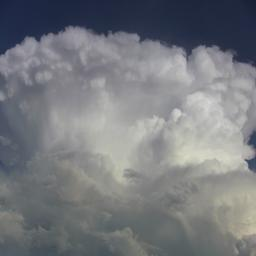

In [21]:
img_path = r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_train/cumulonimbus clouds/c055e7211864fa6b07e07b87bb4ecbe4.jpg'
img = Image.open(img_path)
img.show()

### 1 - Training transformations

Adding random transformations to the original images is a common technique know as **data augmentation**.

- Horizontal flip
- Random rotation
- Auto contrats adjustment
- Parse each image to Tensor
- Resize each image to 64 x 64

In [22]:
train_transforms = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45), # Data Augmentation
    transforms.RandomAutocontrast(),
    transforms.ToTensor(),    
    # transforms.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225]
    #)
])

Training image tranformed example.

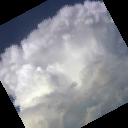

In [23]:
img_transformed = train_transforms(img)
img_pil = F.to_pil_image(img_transformed)
img_pil.show()

In [24]:
train_dataset = ImageFolder(
    root=r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_train',
    transform=train_transforms
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    shuffle=True,
    batch_size=10
)

Data sample.

In [25]:
image, label = next(iter(train_dataloader))
print(image.shape)
print(label)

# 10 for batch size of 10
# 3 for the three color channels
# 128 by 128 pixels: height and width.

torch.Size([10, 3, 128, 128])
tensor([1, 4, 4, 3, 3, 3, 4, 5, 6, 4])


To display a color images like this, it must be rearrange so the height and width come before the channels.

torch.Size([128, 128, 3])


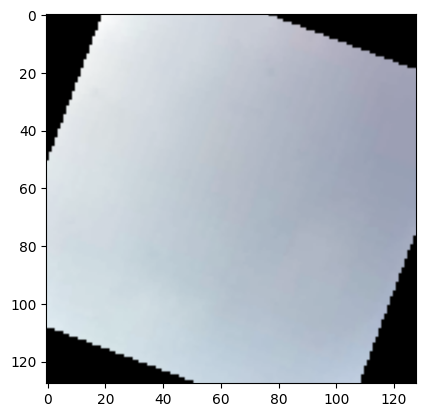

In [26]:
single_image = image[0]  # Shape: [3, 128, 128]
single_label = label[0]  # Single label

single_image = single_image.squeeze().permute(1, 2, 0)
print(single_image.shape)
plt.imshow(single_image)
plt.show()

### 2 - Validation and test transformations

In [27]:
test_transforms = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.ToTensor(),    
    # transforms.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225]
    # )
])

Validation dataset and dataloader.

In [28]:
valid_dataset = ImageFolder(
    root=r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_validation',
    transform=test_transforms
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    shuffle=True,
    batch_size=10
)

Test dataset and dataloader.

In [29]:
test_dataset = ImageFolder(
    root=r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_test',
    transform=test_transforms
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    shuffle=True,
    batch_size=10
)

### 3 - Convolutional Neural Networks

 Convolutional Neural Networks (CNN) - Core Concepts

Input Representation
* **Images classification**: Task of assigning labels to images based on their content
* **Pixel**: Basic unit of a digital image with intensity values
* **Matrices n1 x n2**: Images represented as 2D arrays (grayscale) or 3D tensors (RGB with channels)

Convolutional Layer
* **Convolution process**: Mathematical operation that slides filters over input to extract features
* **Filter or kernel**: Small matrix of learnable weights that detects specific patterns (edges, textures)
* **Feature map (activation map)**: Output produced when a filter is applied across the input
* **Padding**: Adding zeros around input borders; same padding keeps output size equal to input
* **Stride**: Step size for moving the filter; larger stride = smaller output
* **Receptive field**: Region of input that influences a particular feature in the output

Pooling Layer
* **Subsampling layer (pooling)**: Reduces spatial dimensions while retaining important features
* **Max pooling**: Takes maximum value from each pooling window
* **Local invariance**: Small translations in input don't drastically change output
* **Reduce overfitting**: Pooling adds robustness and decreases parameters

Architecture Components
* **Depth (number of filters)**: How many different features are extracted at each layer
* **Fully connected layer**: Final layers that perform classification using extracted features
* **Activation function**: Non-linearity (ReLU, sigmoid) applied after convolutions
* **Flattening**: Converting 2D feature maps to 1D vector before fully connected layers

Taker from Machine Learning with PyTorch and Scikit-Learn, pag 474.  
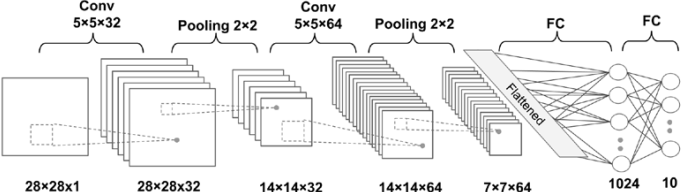

### 4 - Training, validation and test sets

In [30]:
folder_path = r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data'
def count_images(folder_path: str) -> pl.DataFrame:
    data = []
    for i in ['clouds_train', 'clouds_validation', 'clouds_test']:
        path = os.path.join(folder_path, i)
        for name in sorted(os.listdir(path)):
            second_folder = os.path.join(path, name)
            row={'category': name, 'images': len(glob.glob(f'{second_folder}/*.jpg')), 'base': i}
            data.append(row)
    df = (
        pl.DataFrame(data=data)
        .pivot(on=['base'], index=['category'], values=['images'])
    )
    return df

count_images(folder_path=folder_path)

category,clouds_train,clouds_validation,clouds_test
str,i64,i64,i64
"""cirriform clouds""",86,27,30
"""clear sky""",75,19,30
"""cumulonimbus clouds""",17,3,5
"""cumulus clouds""",126,37,48
"""high cumuliform clouds""",163,33,40
"""stratiform clouds""",60,14,15
"""stratocumulus clouds""",76,21,35


### 5 - Training image classifiers

Loss functions:

- Binary classification: binary cross-entropy (BCE) loss.
- Multi-class classification: cross-entropy loss

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = dlclasses.MyCNN(num_classes=7)
net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=net.parameters(), lr=0.0001)

Option 1: Running a single training loop to compute the loos per epoch.

In [32]:
for epoch in range(2):
    running_loss = 0.0
    for images, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_dataloader)
    print(f'Epoch {epoch + 1}, Loss: {epoch_loss:.4f}')

Epoch 1, Loss: 1.8394
Epoch 2, Loss: 1.7082


Option 2: training and validation loop usign accuracy metric.
Adapted from Machine Learning with PyTorch and Scikit-Learn (page 479)

In [33]:
def train_cnn(
    model,  num_epochs,  train_dataloader,  valid_dataloader,  loss_function, optimizer, device
) -> tuple[list[float], list[float], list[float], list[float]]:
    
    loss_hist_train = [0.0] * num_epochs
    accuracy_hist_train = [0.0] * num_epochs
    loss_hist_valid = [0.0] * num_epochs
    accuracy_hist_valid = [0.0] * num_epochs

    epoch_bar = tqdm(range(num_epochs), file=sys.stdout, dynamic_ncols=False)
    for epoch in epoch_bar:
        model.train()
        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            pred = model(images)
            loss = loss_function(pred, labels)
            loss.backward()
            optimizer.step()
            loss_hist_train[epoch] += loss.item() * labels.size(0)
            is_correct = (torch.argmax(pred, dim=1) == labels).float()
            accuracy_hist_train[epoch] += is_correct.sum().item()
        
        loss_hist_train[epoch] /= len(train_dataloader.dataset)
        accuracy_hist_train[epoch] /= len(train_dataloader.dataset)

        model.eval()
        with torch.no_grad():
            for images, labels in valid_dataloader:
                images, labels = images.to(device), labels.to(device)
                pred = model(images)
                loss = loss_function(pred, labels)
                loss_hist_valid[epoch] += loss.item() * labels.size(0)
                is_correct = (torch.argmax(pred, dim=1) == labels).float()
                accuracy_hist_valid[epoch] += is_correct.sum().item()

        loss_hist_valid[epoch] /= len(valid_dataloader.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dataloader.dataset)

        tqdm.write(
            f'Epoch {epoch + 1} Accuracy: {accuracy_hist_train[epoch]:.4f} '
            f'Validation Accuracy: {accuracy_hist_valid[epoch]:.4f}',
            file=sys.stdout
        )
        epoch_bar.update(0)
        
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid


In [35]:
# torch.manual_seed(1)
hist = train_cnn(
    model=net,
    num_epochs=40,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_function=criterion,
    optimizer=optimizer,
    device=device
)

Epoch 1 Accuracy: 0.6086 Validation Accuracy: 0.5584
Epoch 2 Accuracy: 0.6169 Validation Accuracy: 0.6169
Epoch 3 Accuracy: 0.6086 Validation Accuracy: 0.5844
Epoch 4 Accuracy: 0.6020 Validation Accuracy: 0.6169
Epoch 5 Accuracy: 0.6584 Validation Accuracy: 0.5909
Epoch 6 Accuracy: 0.6252 Validation Accuracy: 0.5844
Epoch 7 Accuracy: 0.5937 Validation Accuracy: 0.6623
Epoch 8 Accuracy: 0.6567 Validation Accuracy: 0.6234
Epoch 9 Accuracy: 0.6335 Validation Accuracy: 0.6299
Epoch 10 Accuracy: 0.6385 Validation Accuracy: 0.5779
Epoch 11 Accuracy: 0.6517 Validation Accuracy: 0.6753
Epoch 12 Accuracy: 0.6683 Validation Accuracy: 0.6818
Epoch 13 Accuracy: 0.6849 Validation Accuracy: 0.6753
Epoch 14 Accuracy: 0.6733 Validation Accuracy: 0.6299
Epoch 15 Accuracy: 0.6750 Validation Accuracy: 0.6558
Epoch 16 Accuracy: 0.6949 Validation Accuracy: 0.6948
Epoch 17 Accuracy: 0.6783 Validation Accuracy: 0.6818
Epoch 18 Accuracy: 0.6617 Validation Accuracy: 0.6688
Epoch 19 Accuracy: 0.6783 Validation 